In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #FOR FIT NEW DATA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris


In [2]:
from sklearn.datasets import load_iris
# Load iris dataset from sklearn
iris = load_iris() 

In [3]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target # Add the target variable


In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
df.isnull().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [8]:
df.duplicated().sum()


np.int64(1)

In [9]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [10]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

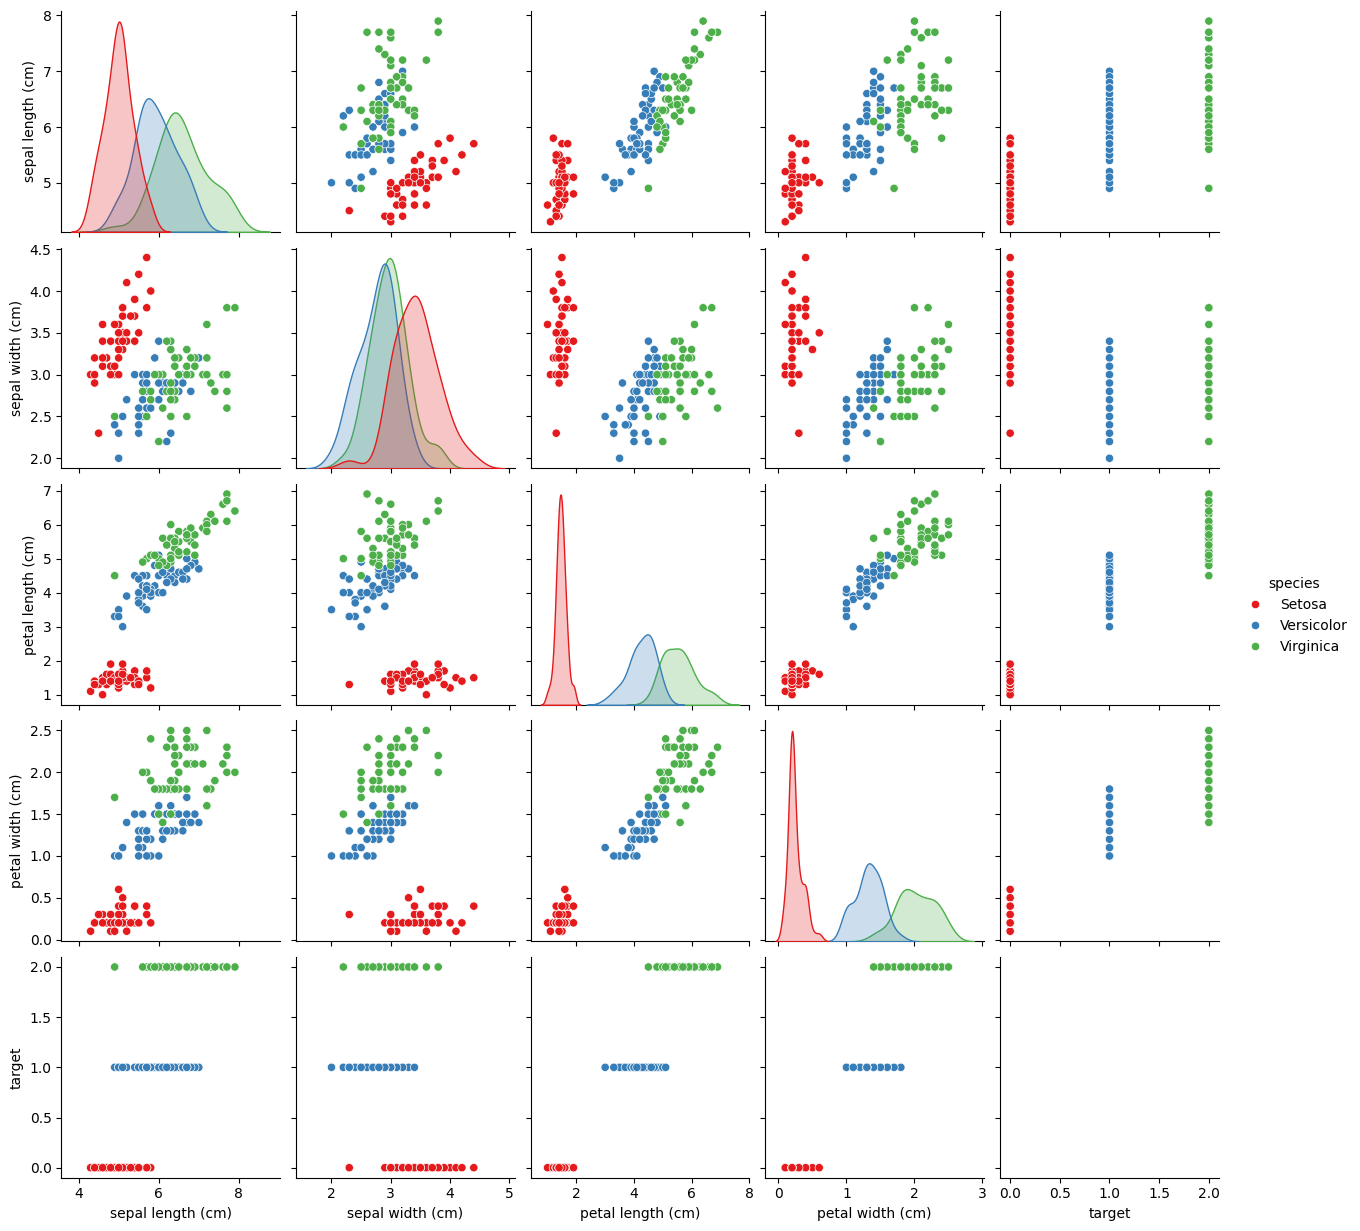

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# Map numerical target labels to flower species names for easier interpretation in plots
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
# Create a pairplot to visualize the relationship between all pairs of features, colored by species
sns.pairplot(df, hue='species', palette='Set1')
plt.show()

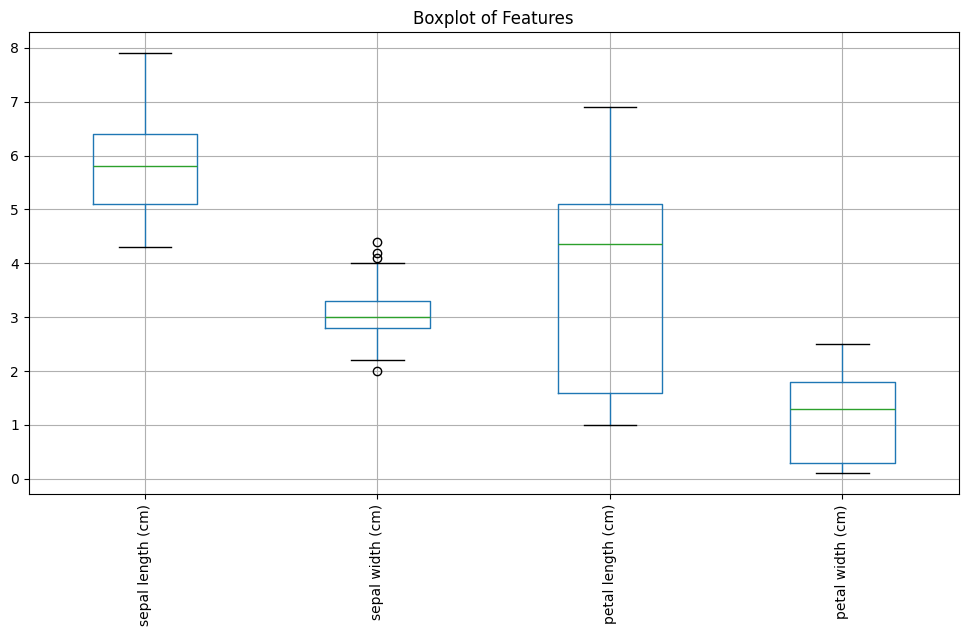

In [12]:
plt.figure(figsize=(12, 6))
df.drop(columns=['target']).boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=90)
plt.show()


<Figure size 1000x800 with 0 Axes>

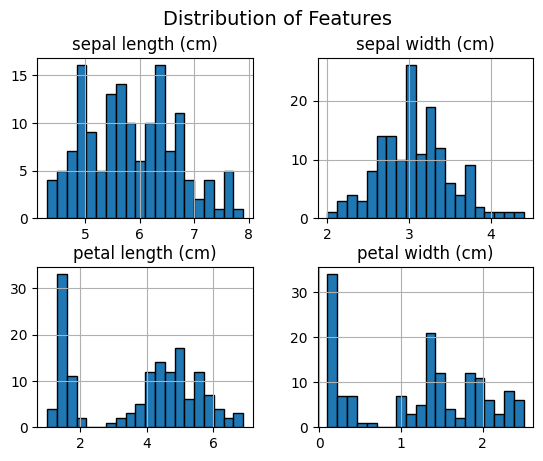

In [13]:
# Plot histograms to see the distribution of values for each feature
plt.figure(figsize=(10, 8))
df.drop(columns=['target']).hist(bins=20, edgecolor='black')
plt.suptitle("Distribution of Features", fontsize=14)
plt.show()


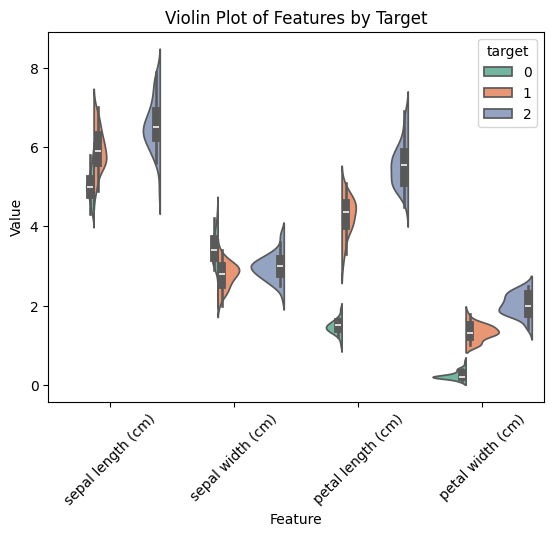

In [14]:
 #Select only numeric feature columns (exclude target)
feature_cols = df.drop(columns=['target']).select_dtypes(include='number').columns
 
# Melt only numeric features
df_melted = df.melt(
    id_vars='target',
    value_vars=feature_cols,
    var_name='Feature',
    value_name='Value'
)
 
# Plot violin plot
sns.violinplot(
    x="Feature",
    y="Value",
    hue="target",
    data=df_melted,
    split=True,
    palette="Set2"
)
 
plt.xticks(rotation=45)
plt.title("Violin Plot of Features by Target")
plt.show()


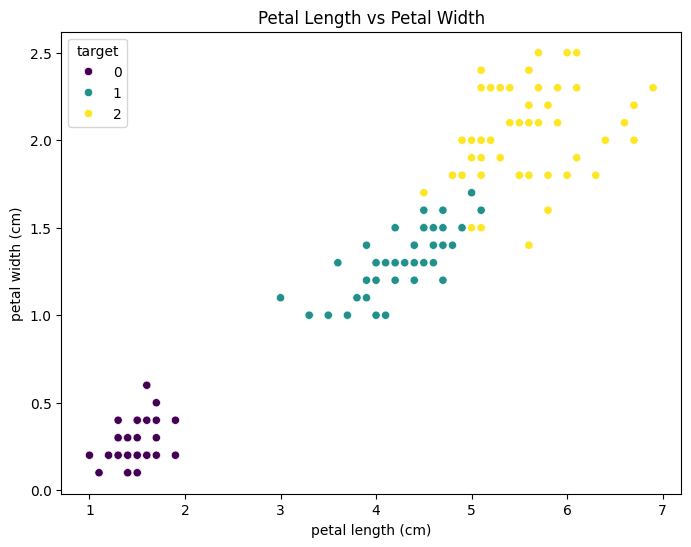

In [15]:
# Scatter plot for petal length vs. petal width colored by target class
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'], hue=df["target"], 
palette="viridis")
plt.title("Petal Length vs Petal Width")
plt.show()

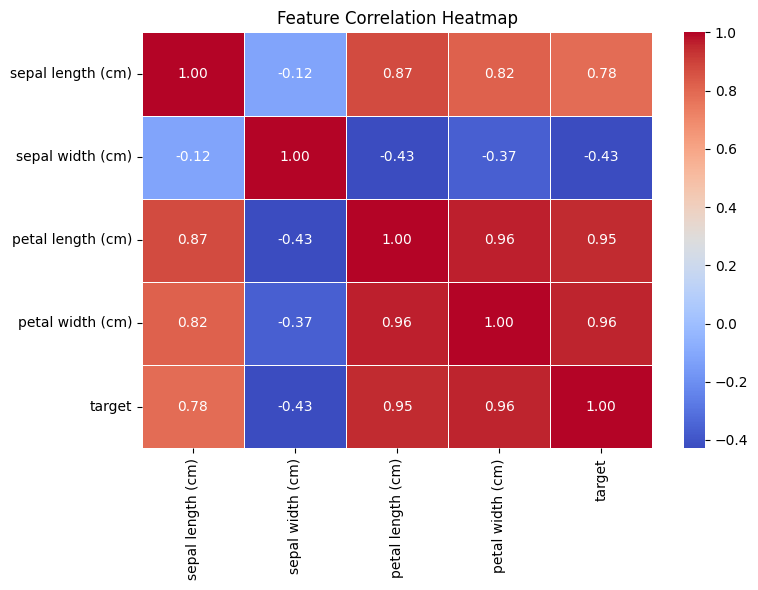

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Select only numeric columns
correlation = df.select_dtypes(include=['number']).corr()

sns.heatmap(correlation, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [17]:
X = df.drop(columns=['target', 'species']) # Features
# y will contain the output/label we're trying to predict (target column)
y = df['target'] # Target (class labels: 0, 1, 2 for flower species)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:

X = df.drop(columns=['target', 'species']) # Features
# y will contain the output/label we're trying to predict (target column)
y = df['target'] # Target (class labels: 0, 1, 2 for flower species)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Standardizing the features
from sklearn.preprocessing import StandardScaler
# Step 1: Create a StandardScaler object
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Initialize the Logistic Regression model
log_reg = LogisticRegression()
# Train the model using training data
log_reg.fit(X_train, y_train)
# Predict the labels for test set
y_pred_log = log_reg.predict(X_test)
# Evaluate the model's performance
accuracy_log_reg = accuracy_score(y_test, y_pred_log) # Accuracy Score
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log) # Confusion Matrix
class_report_log_reg = classification_report(y_test, y_pred_log) # Classification Report
# Print evaluation metrics
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.2f}")
print("Confusion Matrix:")
print(conf_matrix_log_reg)
print("Classification Report:")
print(class_report_log_reg)


Logistic Regression Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [21]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
# Initialize the Decision Tree model
tree_clf = DecisionTreeClassifier()
# Train the model
tree_clf.fit(X_train, y_train)
# Predict labels for test set
y_pred_tree = tree_clf.predict(X_test)
# Evaluate the model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
class_report_tree = classification_report(y_test, y_pred_tree)
# Print evaluation metrics
print(f'Decision Tree Accuracy: {accuracy_tree:.2f}')
print('Confusion Matrix:')
print(conf_matrix_tree)
print('Classification Report:')
print(class_report_tree)


Decision Tree Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
# Import k-NN Classifier
from sklearn.neighbors import KNeighborsClassifier
# Initialize k-NN model with 5 neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5)
# Train the model
knn_clf.fit(X_train, y_train)
# Predict labels for test set
y_pred_knn = knn_clf.predict(X_test)
# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)
# Print evaluation metrics
print(f'k-NN Accuracy: {accuracy_knn:.2f}')
print('Confusion Matrix:')
print(conf_matrix_knn)
print('Classification Report:')
print(class_report_knn)

k-NN Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



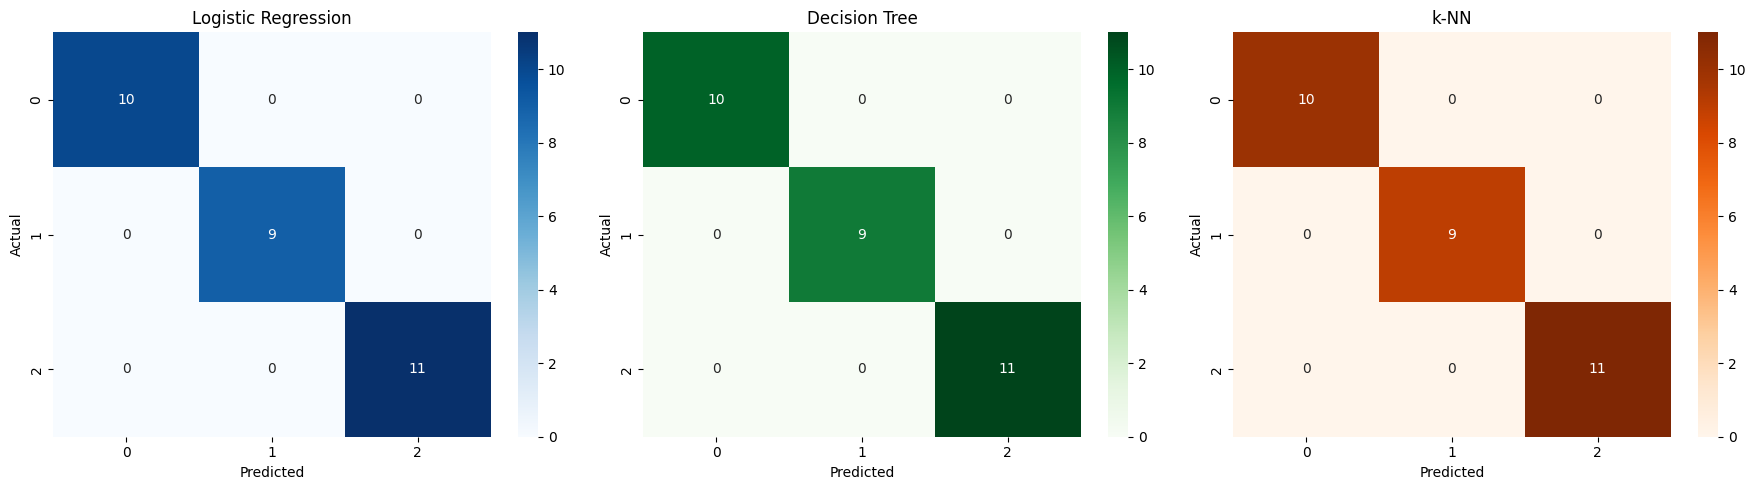

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a subplot with 1 row and 3 columns for visualizing 3 confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot confusion matrix for Logistic Regression
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
# Plot confusion matrix for Decision Tree
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
# Plot confusion matrix for k-Nearest Neighbors
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
# Display the plots
plt.tight_layout()
plt.show()

In [24]:
# Import pickle module
import pickle
# Saving the trained Logistic Regression model to a file using pickle
# 'wb' mode = write binary mode, used to save the model object
with open('log_reg_model.pkl', 'wb') as model_file:
 # Serializes and writes the logistic regression model to a file
    pickle.dump(log_reg, model_file)
# Saving the StandardScaler object to a pickle file
# 'wb' mode = write binary mode, used to save the scaler object
with open('scaler.pkl', 'wb') as scaler_file:
# Serializes and writes the scaler object to a file
    pickle.dump(scaler, scaler_file)

In [25]:
# Import necessary libraries
import pickle
import pandas as pd
# ---------------------------
# Load the trained model and scaler
# ---------------------------
def load_model_and_scaler(model_filename='log_reg_model.pkl', 
scaler_filename='scaler.pkl'):
 """Loads the trained model and scaler from pickle files."""
 
 # Load the trained model from file (update with correct file name if needed)
 with open(r"C:\Users\inter\Desktop\Mansi\Machine Learning\log_reg_model.pkl", 'rb') as model_file:
    model = pickle.load(model_file) # Deserialize model
 # Load the StandardScaler used during training
 with open(r"C:\Users\inter\Desktop\Mansi\Machine Learning\scaler.pkl", 'rb') as scaler_file:
    scaler = pickle.load(scaler_file) # Deserialize scaler
 return model, scaler
# ---------------------------
# Preprocess input using the loaded scaler
# ---------------------------
def preprocess_input(input_data, scaler):
 """Preprocess the input data: convert to DataFrame and scale it using the loaded scaler."""
 
 # Convert the input dictionary to a single-row DataFrame
 input_df = pd.DataFrame([input_data])
 
 # Apply the same scaling used during training
 input_scaled = scaler.transform(input_df)
 
 return input_scaled
# ---------------------------
# Predict the Iris species
# ---------------------------
def predict_iris_species(input_data):
 """Predicts the species of the Iris flower (Setosa, Versicolor, or Virginica)."""
 
 # Load the trained model and scaler
 model, scaler = load_model_and_scaler()
 
 # Preprocess input (apply scaling)
 input_scaled = preprocess_input(input_data, scaler)
 
 # Predict the species (returns 0, 1, or 2)
 prediction = model.predict(input_scaled)
 
 # Map numerical prediction to actual species name
 species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
 predicted_species = species_map[prediction[0]]
 
 return predicted_species
# ---------------------------
# Example Usage
# ---------------------------
# New input sample to classify
new_iris_data = {
 'sepal length (cm)': 5.1,
 'sepal width (cm)': 3.5,
 'petal length (cm)': 1.4,
 'petal width (cm)': 0.2
}
# Call the prediction function
result = predict_iris_species(new_iris_data)
print(f"The predicted species is: {result}")

The predicted species is: setosa


In [26]:
print("Streamlit app saved as 'app.py'")
print("=" * 60)
print("To run the app, use: streamlit run app.py")
print("=" * 60)

Streamlit app saved as 'app.py'
To run the app, use: streamlit run app.py
